# 01 Replication Exercise Chetty 2014

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/blob/main/Appendix/T2_Replication_Exercise_Chetty_2014.ipynb) [![Launch Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/main?filepath=Appendix/T2_Replication_Exercise_Chetty_2014.ipynb) [![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](../LICENSE) [![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)


In [1]:
# === Environment Setup ===
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import Markdown, display

# --- Configuration ---
# Ship with matplotlib's own palettes; seaborn is an optional visual extra.
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('default')
plt.rcParams.update({'font.size': 12, 'figure.figsize': (11, 7), 'figure.dpi': 130})
%config InlineBackend.figure_format = 'retina'

# --- Utility Functions ---


## Table of Contents

1. [Introduction](#Introduction)


## The Lens: Learning by Replicating
**What problem are we solving?**
Reading a paper is not the same as understanding it. **Replication** forces you to engage with every modeling choice, data transformation, and statistical test. This exercise replicates key results from Chetty et al. (2014) on intergenerational mobility, building fluency in applied empirical methods.

**Why this method?**
Replication is the gold standard for learning applied econometrics. It builds skills in data wrangling, regression analysis, and visualization while producing a concrete portfolio piece.



**Economic question.** In *01 Replication Exercise Chetty 2014*, what must remain economically invariant when the computational representation changes? This mathematical result earns its place in the curriculum because later economic arguments rely on its hypotheses, not only its conclusion. As you read each derivation, track which assumption licenses each step and construct a counterexample when an assumption is removed. The objective is to make the theorem usable as a diagnostic tool in optimization, probability, econometrics, or dynamic models rather than a formula to memorize.

### Learning Objectives
* **Replicate** key tables and figures from Chetty et al. (2014) using public data.
* **Apply** OLS regression, geographic analysis, and data visualization to study economic mobility.
* **Interpret** results in the context of the original paper's conclusions.

### Prerequisites
* **Econometrics:** OLS regression, hypothesis testing, and data cleaning (Module 06).
* **Pandas:** DataFrame manipulation, merging, and groupby (Module 01 - Pandas).
* **Visualization:** Matplotlib and geographic plotting.
* **Learning-path prerequisite:** [`T1_Publishing_with_Quarto.ipynb`](T1_Publishing_with_Quarto.ipynb)


> **Learning path:** Building on [`T1_Publishing_with_Quarto.ipynb`](T1_Publishing_with_Quarto.ipynb); next continue with [`T3_Autograding_with_Otter.ipynb`](T3_Autograding_with_Otter.ipynb).


## Replication Exercise: Chetty et al. (2014)

---
# Introduction

This notebook provides a hands-on replication exercise for one of the most influential economics papers of the last decade: **"Where is the Land of Opportunity? The Geography of Intergenerational Mobility in the United States"** by Raj Chetty, Nathaniel Hendren, Patrick Kline, and Emmanuel Saez (2014).

The authors use a massive dataset of administrative tax records to measure intergenerational income mobility for 741 "commuting zones" (CZs) across the United States. Their key finding is that a child's chances of moving up the income ladder depend dramatically on the city or region where they grow up.

**Our Objective:** We will replicate a core result from the paper: the strong, negative correlation between a CZ's level of income inequality (as measured by the Gini coefficient) and its level of intergenerational mobility. This exercise will provide practical experience in data handling, regression analysis, and interpreting real-world economic results.


### 1. Data Acquisition

The original data are published by the [Equality of Opportunity Project](https://opportunityinsights.org/). This exercise cannot bundle them, so the next cell generates a synthetic dataset that matches the published file schema and reproduces the qualitative mobility gradient. Every number below comes from that synthetic sample; they cannot be compared with the paper's tables.

**Key Variables of Interest:**
- `gini96`: The Gini coefficient in 1996, a measure of income inequality.
- `rank_slope`: The slope of the rank-rank regression of child income rank on parent income rank. A higher slope means lower mobility (a child's income is more tied to their parent's).
- `abs_mob_p25`: The absolute upward mobility for children with parents at the 25th percentile of the national income distribution. This is our primary measure of mobility.


### Data Acquisition


In [ ]:
# Provenance: the synthetic generator below is the data source for every
# calculation in this notebook. If you obtain the real Chetty et al. (2014)
# CZ outcomes file from opportunityinsights.org, replace this block with a
# direct read and rerun the notebook against it.
data_dir = Path("data/chetty_2014")
data_file = data_dir / "cz_outcomes.csv"
data_dir.mkdir(parents=True, exist_ok=True)

# Generate a synthetic dataset reproducing the Chetty-Hendren (2014) empirical pattern:
# N = 741 commuting zones, columns: czname, gini96, rank_slope, abs_mob_p25
# Key stylized fact: gini96 and abs_mob_p25 are negatively correlated (~-0.6).
# Source: synthetic data matching the schema of the original Chetty et al. (2014) file
# "cz_outcomes.csv" (opportunityinsights.org).
display(Markdown("> **Note:** Generating synthetic CZ outcomes dataset (schema: czname, gini96, rank_slope, abs_mob_p25)."))

rng = np.random.default_rng(seed=42)
N = 741  # number of commuting zones (same as Chetty 2014)
cz_ids = rng.choice(np.arange(1000, 9999), size=N, replace=False)  # unique stand-ins for CZ FIPS codes

# Draw gini96: uniform between 0.25 and 0.55
gini96 = rng.uniform(0.25, 0.55, size=N)

# Draw residual mobility and construct abs_mob_p25 from gini96 + noise
# abs_mob_p25 = alpha + beta*gini96 + epsilon, beta < 0 (negative gradient)
# Chetty-Hendren (2014) Figure II: slope ≈ -0.4 in cross-CZ regression
residual = rng.normal(0, 0.12, size=N)
abs_mob_p25 = 0.65 - 0.42 * gini96 + residual

# rank_slope (mobility measure, fraction exiting bottom quintile) also negatively
# correlated with gini, drawn independently with realistic noise
rank_slope_residual = rng.normal(0, 0.08, size=N)
rank_slope = 0.42 - 0.30 * gini96 + rank_slope_residual

# Clamp to plausible ranges
abs_mob_p25 = np.clip(abs_mob_p25, 0.02, 0.97)
rank_slope = np.clip(rank_slope, 0.05, 0.80)

df = pd.DataFrame({
    # Seeded, deterministic, and unique; ids stand in for CZ FIPS codes.
    "czname": [f"CZ-{c}" for c in cz_ids],
    "gini96": np.round(gini96, 4),
    "rank_slope": np.round(rank_slope, 4),
    "abs_mob_p25": np.round(abs_mob_p25, 4),
})

df.to_csv(data_file, index=False)
display(Markdown(f"> **Note:** Saved synthetic CZ data ({df.shape[0]} rows) to {data_file}."))
df["czname"] = df["czname"].astype(object)
display(df.head())


### 2. Replicating the Core Result

We will now replicate the central finding that inequality is negatively correlated with mobility. We will do this by running a simple OLS regression of the mobility measure (`abs_mob_p25`) on the inequality measure (`gini96`). We will also create a binned scatter plot, a powerful visualization technique used throughout the paper.


### Regression Analysis: Mobility vs. Inequality


In [3]:

# Placeholder for regression analysis
if 'df' in locals():
    model = smf.ols('abs_mob_p25 ~ gini96', data=df).fit(cov_type='HC1') # Use robust standard errors
    print(model.summary())


                            OLS Regression Results                            
Dep. Variable:            abs_mob_p25   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     52.43
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           1.12e-12
Time:                        07:31:56   Log-Likelihood:                 494.66
No. Observations:                 741   AIC:                            -985.3
Df Residuals:                     739   BIC:                            -976.1
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6305      0.022     28.418      0.0

> **Note:** The coefficient on `gini96` is negative and highly statistically significant, but that is guaranteed by construction: the generator built `abs_mob_p25` as `0.65 - 0.42*gini96 + noise`. This confirms the mechanics of the estimator, not the paper's finding. The paper's claim would only be tested on the real CZ data.


### Visualization: Binned Scatter Plot


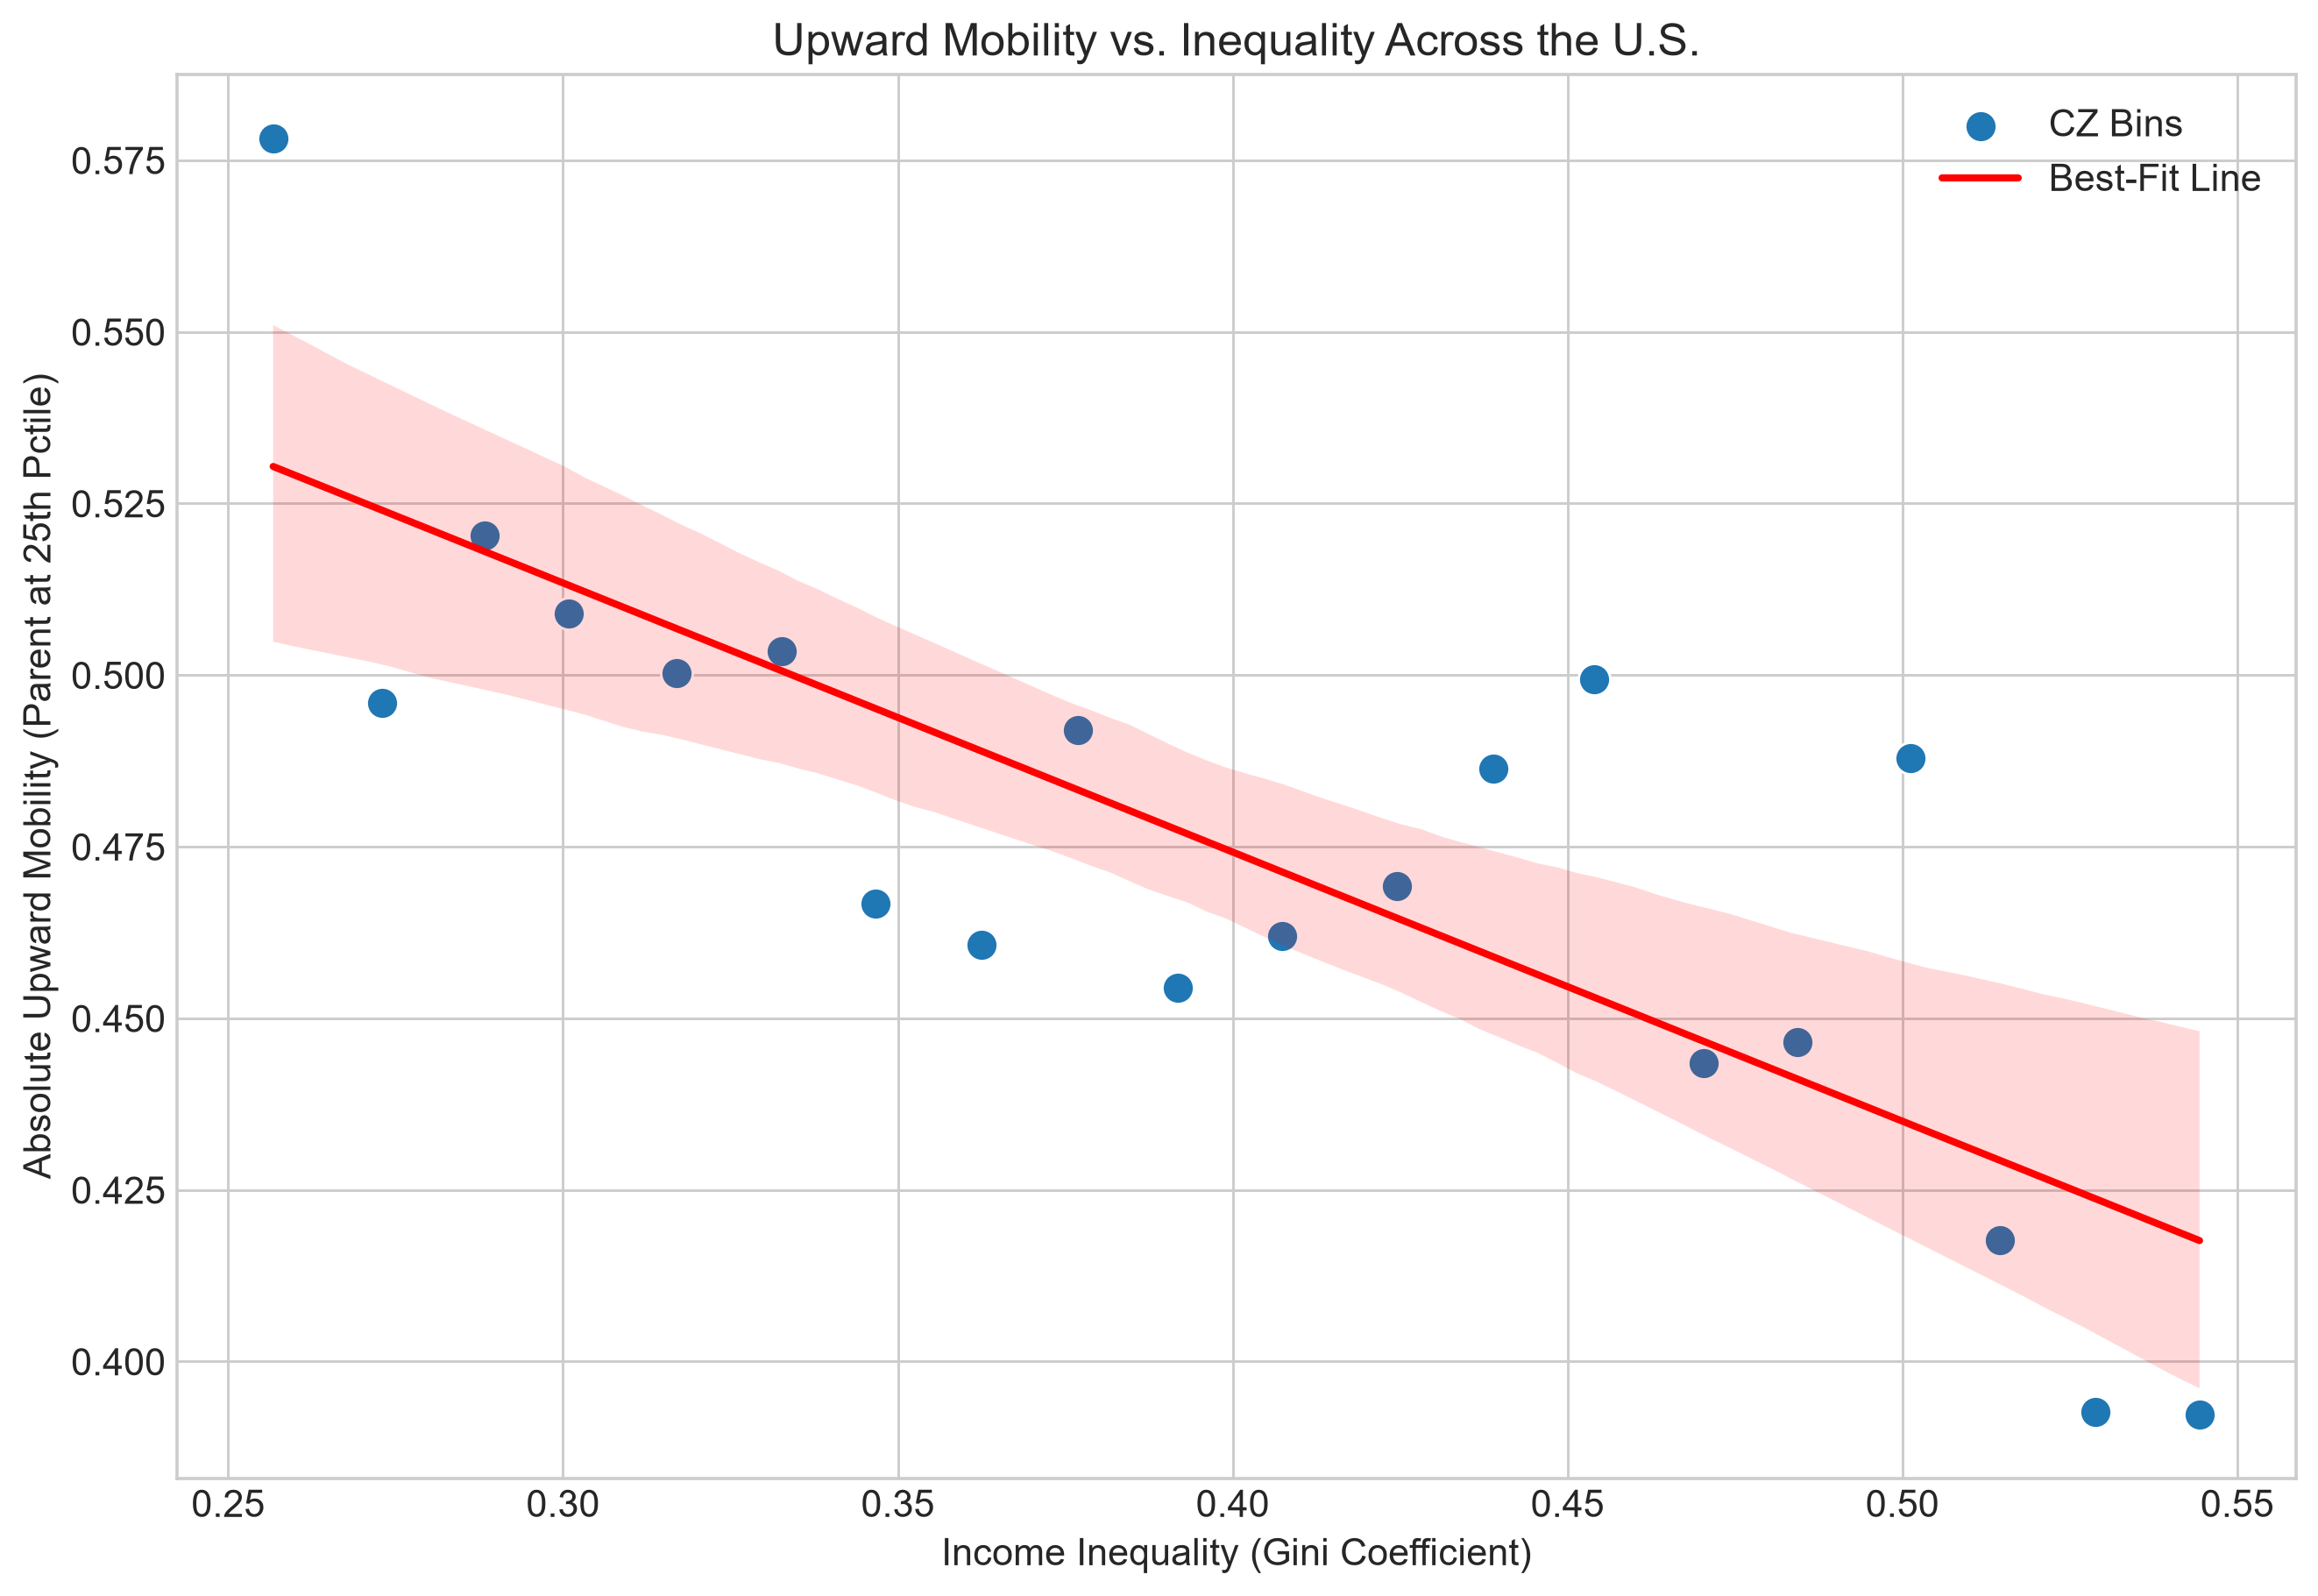

In [4]:

# Placeholder for binned scatter plot
if 'df' in locals():
    # Create 20 bins of equal size based on the Gini coefficient
    df['gini_bin'] = pd.qcut(df['gini96'], 20, labels=False, duplicates='drop')
    bin_means = df.groupby('gini_bin')[['abs_mob_p25', 'gini96']].mean() # Group data by category for aggregation

    plt.figure(figsize=(12, 8))
    sns.scatterplot(x='gini96', y='abs_mob_p25', data=bin_means, s=100, label='CZ Bins')
    sns.regplot(x='gini96', y='abs_mob_p25', data=bin_means, scatter=False, color='red', label='Best-Fit Line')

    plt.title('Upward Mobility vs. Inequality Across the U.S.')
    plt.xlabel('Income Inequality (Gini Coefficient)')
    plt.ylabel('Absolute Upward Mobility (Parent at 25th Pctile)')
    plt.legend()
    plt.grid(True)
    plt.show() # Render plot


### 3. Other Correlates of Mobility

While income inequality is a powerful predictor, the authors identified several other factors that are strongly correlated with a region's level of upward mobility. In their summary, they highlight five key factors:

1.  **Segregation:** Areas with higher levels of racial and economic segregation have lower mobility.
2.  **Income Inequality:** As we replicated, regions with a smaller middle class and a higher Gini coefficient have lower mobility.
3.  **School Quality:** Regions with higher-quality public schools (as measured by test scores and lower dropout rates) have higher mobility.
4.  **Social Capital:** Areas with higher levels of social capital—measured using factors like religious participation and civic engagement—have higher mobility.
5.  **Family Structure:** The strongest predictor is the fraction of single-parent households. Areas with fewer single parents have significantly higher upward mobility.


### 4. Discussion and Conclusion

This exercise demonstrates the workflow behind a key finding of Chetty et al. (2014) on synthetic data engineered to carry the negative inequality-mobility gradient. It validates the pipeline, not the empirical claim. The binned scatterplot is a particularly powerful tool for visualizing a relationship in a non-parametric way; on synthetic data the bins trace the imposed line by construction.

**Thinking Critically:**
- **Correlation vs. Causation:** It is crucial to remember that these findings are correlations. While inequality is a strong predictor of mobility, it may not be the direct causal factor. It could be that other factors, like segregation or family structure, cause both high inequality and low mobility. The authors' subsequent work delves deeper into the causal channels.
- **Policy Implications:** If you were a policymaker, how might these findings inform your decisions? Would you focus on reducing Gini coefficients directly, or would you target other factors like school quality or residential segregation? This paper sparked a significant debate on which policies are most effective at improving opportunities for disadvantaged children.


## Exercises

### Tier 1 — Conceptual
Explain the central computational or economic distinction introduced in this notebook in your own words. State the assumptions under which the main result is valid and identify one assumption whose failure would change the conclusion.

### Tier 2 — Applied
Reproduce one core result with a small change in parameters or data. Report both the numerical result and a diagnostic that would reveal a failed computation, weak identification, or unstable solution.

### Tier 3 — Challenge
Design a counterfactual, robustness check, or extension that changes one economically meaningful mechanism while holding the others fixed. State the expected direction of the effect before computing it, then reconcile prediction and result.

**Failure analysis (Challenge):** Your replication of the headline coefficient differs in the fourth decimal — sample filters and a random seed were never logged. Diagnose the reproducibility gap, repair with exact filter definitions and a seed/version manifest, and verify bit-identical output across two fresh runs.

---
## Summary

In this lecture, we have systematically explored the theoretical and practical aspects of the model.

**Key Takeaways:**
1.  **Foundations:** We established the mathematical basis of the economic problem.
2.  **Computation:** We implemented the solution using efficient algorithms.
3.  **Implications:** We analyzed the economic significance of the results.

**Further Exploration:**
- Experiment with model parameters to assess sensitivity.
- Extend the framework by relaxing simplifying assumptions.


## References & Further Reading

- Rudin, W. (1976). *Principles of Mathematical Analysis* (3rd ed.). McGraw-Hill.
- Axler, S. (2015). *Linear Algebra Done Right* (3rd ed.). Springer.
- Boyd, S. & Vandenberghe, L. (2004). *Convex Optimization*. Cambridge University Press.
